# Notebook 07 — Mouth State Classification

## Custom CNN + MobileNetV2

This notebook trains two dedicated models for the mouth-state task:

1. **Custom CNN**
2. **MobileNetV2 Transfer Learning**

Classes:

- `no_yawn`
- `yawn`

We will measure:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion matrix
- Per-class performance
- Prediction confidence



## 0. Imports and configuration

In [1]:
from pathlib import Path
import json
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))


TensorFlow: 2.21.0
Keras: 3.15.1
GPU devices: []


In [2]:
PROJECT_ROOT = (
    Path.cwd().parent
    if Path.cwd().name == "notebooks"
    else Path.cwd()
)

MOUTH_DATASET_DIR = PROJECT_ROOT / "mouth_dataset"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
MODEL_DIR = PROJECT_ROOT / "models"

for folder in [OUTPUT_DIR, MODEL_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

TRAIN_DIR = MOUTH_DATASET_DIR / "train"
VAL_DIR = MOUTH_DATASET_DIR / "validation"
TEST_DIR = MOUTH_DATASET_DIR / "test"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
CLASS_NAMES = ["no_yawn", "yawn"]

print("Project root:", PROJECT_ROOT)
print("Mouth dataset:", MOUTH_DATASET_DIR)
print("Train:", TRAIN_DIR)
print("Validation:", VAL_DIR)
print("Test:", TEST_DIR)


Project root: d:\driver-drowsiness-detection
Mouth dataset: d:\driver-drowsiness-detection\mouth_dataset
Train: d:\driver-drowsiness-detection\mouth_dataset\train
Validation: d:\driver-drowsiness-detection\mouth_dataset\validation
Test: d:\driver-drowsiness-detection\mouth_dataset\test


## 1. Verify the prepared mouth dataset

In [3]:
required_dirs = [
    TRAIN_DIR / "no_yawn",
    TRAIN_DIR / "yawn",
    VAL_DIR / "no_yawn",
    VAL_DIR / "yawn",
    TEST_DIR / "no_yawn",
    TEST_DIR / "yawn"
]

missing_dirs = [
    str(path)
    for path in required_dirs
    if not path.exists()
]

if missing_dirs:
    raise FileNotFoundError(
        "Missing mouth dataset folders:\n" +
        "\n".join(missing_dirs)
    )

def count_images(folder):
    extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
    return sum(
        1
        for path in folder.rglob("*")
        if path.is_file() and path.suffix.lower() in extensions
    )

distribution = []

for split, root in [
    ("train", TRAIN_DIR),
    ("validation", VAL_DIR),
    ("test", TEST_DIR)
]:
    for cls in CLASS_NAMES:
        distribution.append({
            "split": split,
            "class": cls,
            "images": count_images(root / cls)
        })

distribution_df = pd.DataFrame(distribution)

display(
    distribution_df.pivot(
        index="split",
        columns="class",
        values="images"
    )
)

if (distribution_df["images"] == 0).any():
    raise ValueError("One or more mouth dataset classes contain zero images.")

print("\nTotal images:", distribution_df["images"].sum())


class,no_yawn,yawn
split,,
test,118,103
train,500,504
validation,107,116



Total images: 1448


## 2. Load train, validation and test datasets




In [4]:
train_ds = keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="binary",
    class_names=CLASS_NAMES,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_ds = keras.utils.image_dataset_from_directory(
    VAL_DIR,
    labels="inferred",
    label_mode="binary",
    class_names=CLASS_NAMES,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels="inferred",
    label_mode="binary",
    class_names=CLASS_NAMES,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Class names:", train_ds.class_names)


Found 1004 files belonging to 2 classes.
Found 223 files belonging to 2 classes.
Found 221 files belonging to 2 classes.
Class names: ['no_yawn', 'yawn']


## 3. Inspect a sample of training images

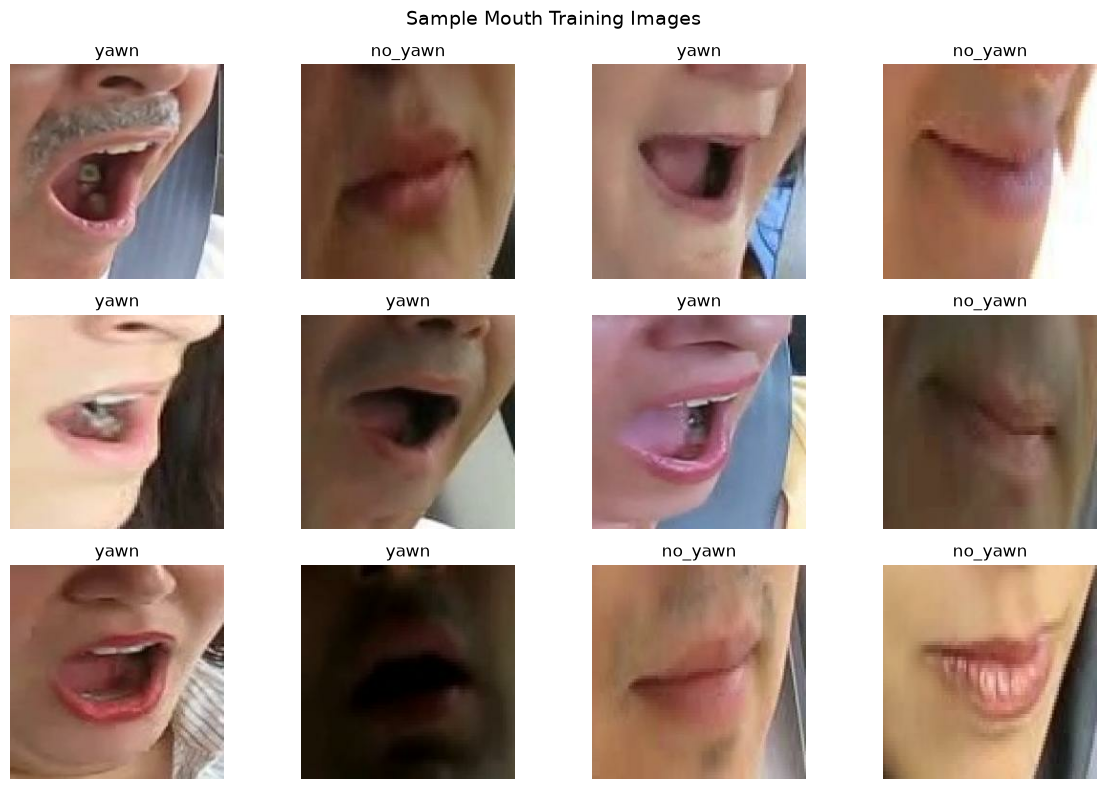

In [5]:
plt.figure(figsize=(12, 8))

for images, labels in train_ds.take(1):
    sample_count = min(12, len(images))

    for i in range(sample_count):
        ax = plt.subplot(3, 4, i + 1)
        ax.imshow(
            tf.cast(images[i], tf.uint8)
        )

        label_index = int(labels[i].numpy()[0])
        ax.set_title(CLASS_NAMES[label_index])
        ax.axis("off")

plt.suptitle(
    "Sample Mouth Training Images",
    fontsize=14
)

plt.tight_layout()
plt.show()


## 4. Create training augmentation



In [6]:
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip(
            "horizontal"
        ),
        layers.RandomRotation(
            0.05
        ),
        layers.RandomTranslation(
            height_factor=0.05,
            width_factor=0.05
        ),
        layers.RandomZoom(
            height_factor=0.08,
            width_factor=0.08
        )
    ],
    name="mouth_augmentation"
)

normalization = layers.Rescaling(
    1.0 / 255.0,
    name="rescaling"
)

print("✓ Training augmentation created.")


✓ Training augmentation created.


## 5. Calculate class weights



In [7]:
train_counts = {}

for cls in CLASS_NAMES:
    train_counts[cls] = count_images(
        TRAIN_DIR / cls
    )

total_train = sum(train_counts.values())
num_classes = len(CLASS_NAMES)

class_weight = {}

for index, cls in enumerate(CLASS_NAMES):
    class_weight[index] = (
        total_train /
        (num_classes * train_counts[cls])
    )

print("Training counts:", train_counts)
print("Class weights:", class_weight)


Training counts: {'no_yawn': 500, 'yawn': 504}
Class weights: {0: 1.004, 1: 0.996031746031746}


## 6. Build the Custom CNN


In [8]:
def build_custom_cnn(input_shape=(224, 224, 3)):
    inputs = keras.Input(
        shape=input_shape,
        name="mouth_input"
    )

    x = data_augmentation(inputs)
    x = normalization(x)

    x = layers.Conv2D(
        32,
        3,
        padding="same",
        activation="relu"
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(
        64,
        3,
        padding="same",
        activation="relu"
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(
        128,
        3,
        padding="same",
        activation="relu"
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(
        256,
        3,
        padding="same",
        activation="relu"
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(
        128,
        activation="relu"
    )(x)

    x = layers.Dropout(
        0.40
    )(x)

    outputs = layers.Dense(
        1,
        activation="sigmoid",
        name="yawn_probability"
    )(x)

    return keras.Model(
        inputs,
        outputs,
        name="mouth_custom_cnn"
    )


custom_cnn = build_custom_cnn()

custom_cnn.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss="binary_crossentropy",
    metrics=[
        keras.metrics.BinaryAccuracy(
            name="accuracy"
        ),
        keras.metrics.Precision(
            name="precision"
        ),
        keras.metrics.Recall(
            name="recall"
        )
    ]
)

custom_cnn.summary()


Model: "mouth_custom_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mouth_input (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mouth_augmentation (Sequential) │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ yawn_probability (Dense)        │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 423,361 (1.61 MB)

 Trainable params: 422,401 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

## 7. Train the Custom CNN

In [9]:
custom_model_path = (
    MODEL_DIR /
    "mouth_custom_cnn_best.keras"
)

custom_callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=str(custom_model_path),
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

custom_start = time.time()

custom_history = custom_cnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=35,
    class_weight=class_weight,
    callbacks=custom_callbacks
)

custom_training_minutes = (
    time.time() - custom_start
) / 60

print(
    f"Training time: "
    f"{custom_training_minutes:.2f} minutes"
)


Epoch 1/35


d:\driver-drowsiness-detection\venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8616 - loss: 0.3202 - precision: 0.8657 - recall: 0.8571
Epoch 1: val_loss improved from None to 1.50458, saving model to d:\driver-drowsiness-detection\models\mouth_custom_cnn_best.keras

Epoch 1: finished saving model to d:\driver-drowsiness-detection\models\mouth_custom_cnn_best.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 86s 3s/step - accuracy: 0.8616 - loss: 0.3202 - precision: 0.8657 - recall: 0.8571 - val_accuracy: 0.4798 - val_loss: 1.5046 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/35
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9502 - loss: 0.1519 - precision: 0.9614 - recall: 0.9385
Epoch 2: val_loss did not improve from 1.50458
32/32 ━━━━━━━━━━━━━━━━━━━━ 69s 2s/step - accuracy: 0.9502 - loss: 0.1519 - precision: 0.9614 - recall: 0.9385 - val_accuracy: 0.4798 - val_loss: 2.7211 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 3/35
32/32 ━━━━━━━━━━━━━━━━━

## 8. Plot Custom CNN training history

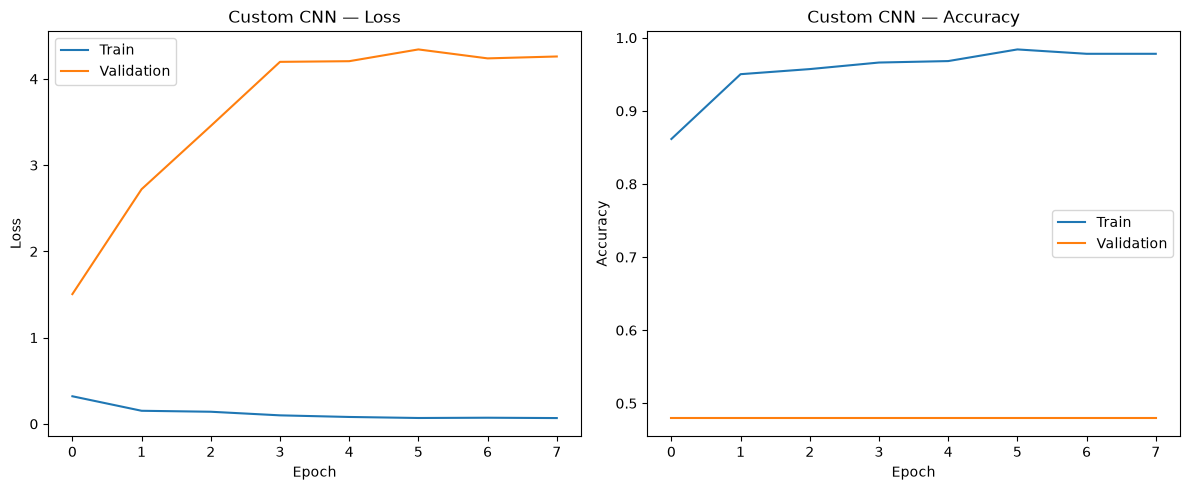

In [10]:
def plot_history(history, title):
    history_df = pd.DataFrame(history.history)

    fig = plt.figure(figsize=(12, 5))

    ax1 = fig.add_subplot(1, 2, 1)
    ax1.plot(history_df["loss"], label="Train")
    ax1.plot(history_df["val_loss"], label="Validation")
    ax1.set_title(f"{title} — Loss")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.legend()

    ax2 = fig.add_subplot(1, 2, 2)
    ax2.plot(history_df["accuracy"], label="Train")
    ax2.plot(history_df["val_accuracy"], label="Validation")
    ax2.set_title(f"{title} — Accuracy")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy")
    ax2.legend()

    plt.tight_layout()
    plt.show()


plot_history(
    custom_history,
    "Custom CNN"
)


## 9. Build MobileNetV2

### Stage 1
The ImageNet-pretrained MobileNetV2 base is frozen and only the classification head is trained.

### Stage 2
The upper part of MobileNetV2 is fine-tuned with a very small learning rate.

Batch-normalization layers remain frozen during fine-tuning for stability.


In [11]:
def build_mobilenetv2():
    inputs = keras.Input(
        shape=(224, 224, 3),
        name="mouth_input"
    )

    x = data_augmentation(inputs)

    # MobileNetV2 preprocessing expects pixels in [-1, 1].
    x = layers.Rescaling(
        scale=1.0 / 127.5,
        offset=-1.0,
        name="mobilenet_preprocessing"
    )(x)

    base_model = keras.applications.MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights="imagenet"
    )

    base_model.trainable = False

    x = base_model(
        x,
        training=False
    )

    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dropout(
        0.35
    )(x)

    outputs = layers.Dense(
        1,
        activation="sigmoid",
        name="yawn_probability"
    )(x)

    model = keras.Model(
        inputs,
        outputs,
        name="mouth_mobilenetv2"
    )

    return model, base_model


mobilenet_model, mobilenet_base = build_mobilenetv2()

mobilenet_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss="binary_crossentropy",
    metrics=[
        keras.metrics.BinaryAccuracy(
            name="accuracy"
        ),
        keras.metrics.Precision(
            name="precision"
        ),
        keras.metrics.Recall(
            name="recall"
        )
    ]
)

mobilenet_model.summary()


Model: "mouth_mobilenetv2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mouth_input (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mouth_augmentation (Sequential) │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenet_preprocessing         │ (None, 224, 224, 3)    │             0 │
│ (Rescaling)                     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ yawn_probability (Dense)        │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 10. Train MobileNetV2 — Stage 1

In [12]:
mobilenet_stage1_path = (
    MODEL_DIR /
    "mouth_mobilenetv2_stage1_best.keras"
)

stage1_callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=str(mobilenet_stage1_path),
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

stage1_start = time.time()

stage1_history = mobilenet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    class_weight=class_weight,
    callbacks=stage1_callbacks
)

stage1_minutes = (
    time.time() - stage1_start
) / 60

print(
    f"Stage 1 training time: "
    f"{stage1_minutes:.2f} minutes"
)


Epoch 1/15


d:\driver-drowsiness-detection\venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 651ms/step - accuracy: 0.8157 - loss: 0.3943 - precision: 0.8235 - recall: 0.8056
Epoch 1: val_loss improved from None to 0.17050, saving model to d:\driver-drowsiness-detection\models\mouth_mobilenetv2_stage1_best.keras

Epoch 1: finished saving model to d:\driver-drowsiness-detection\models\mouth_mobilenetv2_stage1_best.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 32s 828ms/step - accuracy: 0.8157 - loss: 0.3943 - precision: 0.8235 - recall: 0.8056 - val_accuracy: 0.9596 - val_loss: 0.1705 - val_precision: 1.0000 - val_recall: 0.9224 - learning_rate: 0.0010
Epoch 2/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 739ms/step - accuracy: 0.9582 - loss: 0.1437 - precision: 0.9583 - recall: 0.9583
Epoch 2: val_loss improved from 0.17050 to 0.16839, saving model to d:\driver-drowsiness-detection\models\mouth_mobilenetv2_stage1_best.keras

Epoch 2: finished saving model to d:\driver-drowsiness-detection\models\mouth_mobilenetv2_stage1_best.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 28s 891ms/step 

## 11. Fine-tune upper MobileNetV2 layers



In [13]:
mobilenet_base.trainable = True

fine_tune_from = max(
    0,
    len(mobilenet_base.layers) - 30
)

for layer_index, layer in enumerate(
    mobilenet_base.layers
):
    if layer_index < fine_tune_from:
        layer.trainable = False
    else:
        if isinstance(
            layer,
            layers.BatchNormalization
        ):
            layer.trainable = False

trainable_layers = sum(
    int(layer.trainable)
    for layer in mobilenet_base.layers
)

print(
    "MobileNetV2 layers:",
    len(mobilenet_base.layers)
)

print(
    "Trainable base layers:",
    trainable_layers
)

mobilenet_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss="binary_crossentropy",
    metrics=[
        keras.metrics.BinaryAccuracy(
            name="accuracy"
        ),
        keras.metrics.Precision(
            name="precision"
        ),
        keras.metrics.Recall(
            name="recall"
        )
    ]
)


MobileNetV2 layers: 154
Trainable base layers: 19


## 12. Train MobileNetV2 — Stage 2

In [14]:
mobilenet_final_path = (
    MODEL_DIR /
    "mouth_mobilenetv2_best.keras"
)

stage2_callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=str(mobilenet_final_path),
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
]

stage2_start = time.time()

stage2_history = mobilenet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weight,
    callbacks=stage2_callbacks
)

stage2_minutes = (
    time.time() - stage2_start
) / 60

print(
    f"Stage 2 training time: "
    f"{stage2_minutes:.2f} minutes"
)


Epoch 1/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 618ms/step - accuracy: 0.9751 - loss: 0.0708 - precision: 0.9780 - recall: 0.9722
Epoch 1: val_loss improved from None to 0.12690, saving model to d:\driver-drowsiness-detection\models\mouth_mobilenetv2_best.keras

Epoch 1: finished saving model to d:\driver-drowsiness-detection\models\mouth_mobilenetv2_best.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 32s 799ms/step - accuracy: 0.9751 - loss: 0.0708 - precision: 0.9780 - recall: 0.9722 - val_accuracy: 0.9686 - val_loss: 0.1269 - val_precision: 1.0000 - val_recall: 0.9397 - learning_rate: 1.0000e-05
Epoch 2/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 685ms/step - accuracy: 0.9771 - loss: 0.0585 - precision: 0.9744 - recall: 0.9802
Epoch 2: val_loss did not improve from 0.12690
32/32 ━━━━━━━━━━━━━━━━━━━━ 26s 803ms/step - accuracy: 0.9771 - loss: 0.0585 - precision: 0.9744 - recall: 0.9802 - val_accuracy: 0.9641 - val_loss: 0.1336 - val_precision: 1.0000 - val_recall: 0.9310 - learning_rate: 1.0000e-05
Epoch 3/20
32/32 

## 13. Plot MobileNetV2 training history

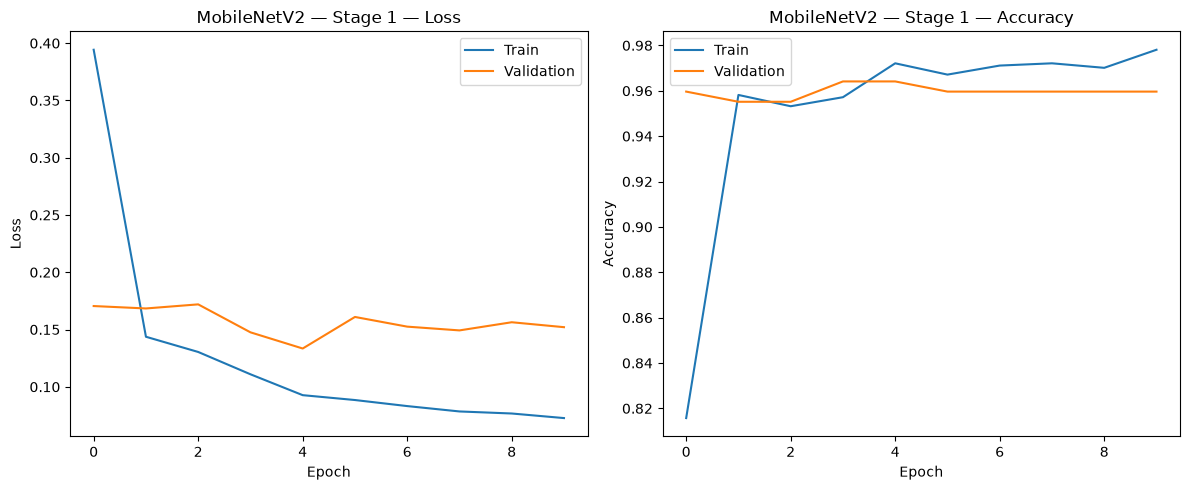

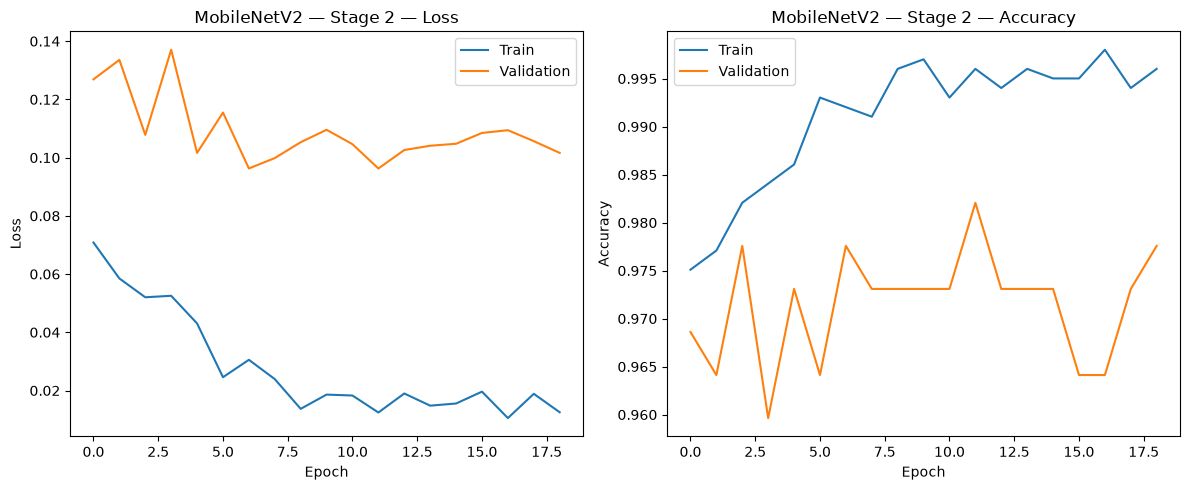

In [15]:
plot_history(
    stage1_history,
    "MobileNetV2 — Stage 1"
)

plot_history(
    stage2_history,
    "MobileNetV2 — Stage 2"
)


# Test Evaluation

## 14. Create a consistent evaluation function



In [16]:
def collect_predictions(model, dataset):
    probabilities = []
    true_labels = []

    for images, labels in dataset:
        batch_probabilities = (
            model.predict(
                images,
                verbose=0
            ).reshape(-1)
        )

        probabilities.extend(
            batch_probabilities.tolist()
        )

        true_labels.extend(
            labels.numpy().reshape(-1).astype(int).tolist()
        )

    probabilities = np.asarray(
        probabilities,
        dtype=np.float32
    )

    true_labels = np.asarray(
        true_labels,
        dtype=np.int32
    )

    predictions = (
        probabilities >= 0.50
    ).astype(int)

    return (
        true_labels,
        probabilities,
        predictions
    )


def evaluate_predictions(
    true_labels,
    probabilities,
    predictions,
    model_name
):
    accuracy = accuracy_score(
        true_labels,
        predictions
    )

    precision = precision_score(
        true_labels,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        true_labels,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        true_labels,
        predictions,
        zero_division=0
    )

    cm = confusion_matrix(
        true_labels,
        predictions,
        labels=[0, 1]
    )

    print(f"\n===== {model_name} =====")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-score : {f1:.4f}")

    print("\nClassification report:")
    print(
        classification_report(
            true_labels,
            predictions,
            labels=[0, 1],
            target_names=CLASS_NAMES,
            zero_division=0
        )
    )

    print("Confusion matrix:")
    print(cm)

    return {
        "model": model_name,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "confusion_matrix": cm
    }


## 15. Evaluate Custom CNN on the test set

In [17]:
custom_true, custom_prob, custom_pred = (
    collect_predictions(
        custom_cnn,
        test_ds
    )
)

custom_metrics = evaluate_predictions(
    custom_true,
    custom_prob,
    custom_pred,
    "Mouth Custom CNN"
)



===== Mouth Custom CNN =====
Accuracy : 0.5339
Precision: 0.0000
Recall   : 0.0000
F1-score : 0.0000

Classification report:
              precision    recall  f1-score   support

     no_yawn       0.53      1.00      0.70       118
        yawn       0.00      0.00      0.00       103

    accuracy                           0.53       221
   macro avg       0.27      0.50      0.35       221
weighted avg       0.29      0.53      0.37       221

Confusion matrix:
[[118   0]
 [103   0]]


## 16. Evaluate MobileNetV2 on the test set

In [18]:
mobilenet_true, mobilenet_prob, mobilenet_pred = (
    collect_predictions(
        mobilenet_model,
        test_ds
    )
)

mobilenet_metrics = evaluate_predictions(
    mobilenet_true,
    mobilenet_prob,
    mobilenet_pred,
    "Mouth MobileNetV2"
)



===== Mouth MobileNetV2 =====
Accuracy : 0.9774
Precision: 1.0000
Recall   : 0.9515
F1-score : 0.9751

Classification report:
              precision    recall  f1-score   support

     no_yawn       0.96      1.00      0.98       118
        yawn       1.00      0.95      0.98       103

    accuracy                           0.98       221
   macro avg       0.98      0.98      0.98       221
weighted avg       0.98      0.98      0.98       221

Confusion matrix:
[[118   0]
 [  5  98]]


## 17. Plot confusion matrices

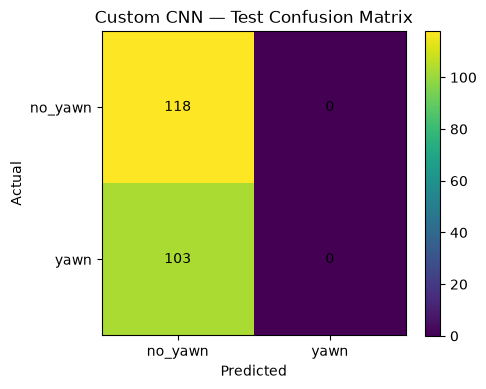

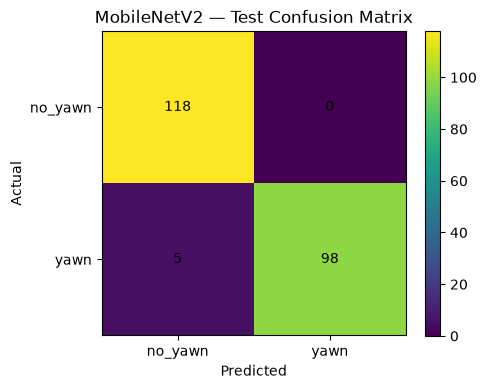

In [19]:
def plot_confusion_matrix(cm, title):
    fig = plt.figure(figsize=(5, 4))
    ax = fig.add_subplot(1, 1, 1)

    image = ax.imshow(cm)

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])

    ax.set_xticklabels(CLASS_NAMES)
    ax.set_yticklabels(CLASS_NAMES)

    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(title)

    for i in range(2):
        for j in range(2):
            ax.text(
                j,
                i,
                str(cm[i, j]),
                ha="center",
                va="center"
            )

    fig.colorbar(
        image,
        ax=ax
    )

    plt.tight_layout()
    plt.show()


plot_confusion_matrix(
    custom_metrics["confusion_matrix"],
    "Custom CNN — Test Confusion Matrix"
)

plot_confusion_matrix(
    mobilenet_metrics["confusion_matrix"],
    "MobileNetV2 — Test Confusion Matrix"
)


## 18. Compare the two models


In [20]:
comparison_rows = []

for metrics in [
    custom_metrics,
    mobilenet_metrics
]:
    cm = metrics["confusion_matrix"]

    # Positive class = yawn.
    yawn_true_positive = int(cm[1, 1])
    yawn_false_negative = int(cm[1, 0])

    comparison_rows.append({
        "Model": metrics["model"],
        "Accuracy": metrics["accuracy"],
        "Precision": metrics["precision"],
        "Recall": metrics["recall"],
        "F1": metrics["f1"],
        "Yawn_TP": yawn_true_positive,
        "Yawn_FN": yawn_false_negative
    })

comparison_df = pd.DataFrame(
    comparison_rows
)

display(
    comparison_df.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}"
    })
)


,Model,Accuracy,Precision,Recall,F1,Yawn_TP,Yawn_FN
0,Mouth Custom CNN,0.5339,0.0000,0.0000,0.0000,0,103
1,Mouth MobileNetV2,0.9774,1.0000,0.9515,0.9751,98,5


## 19. Analyze prediction confidence



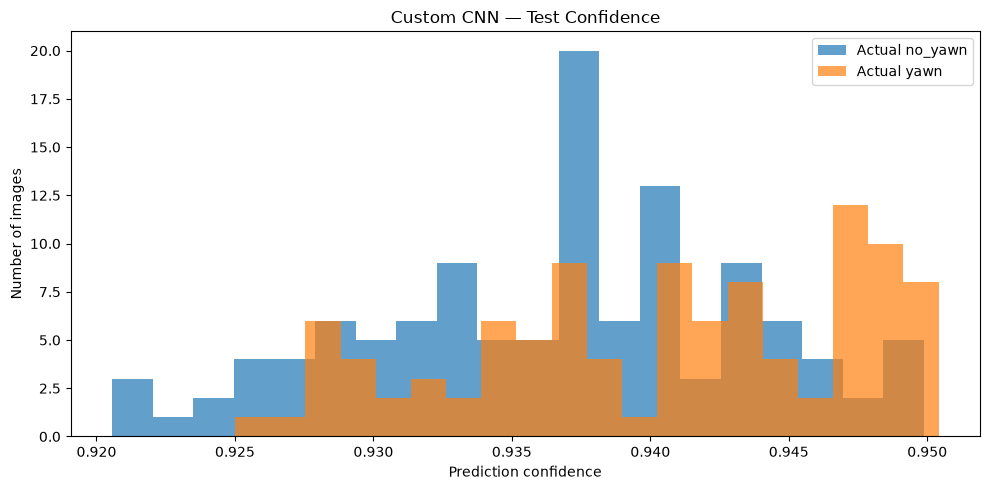

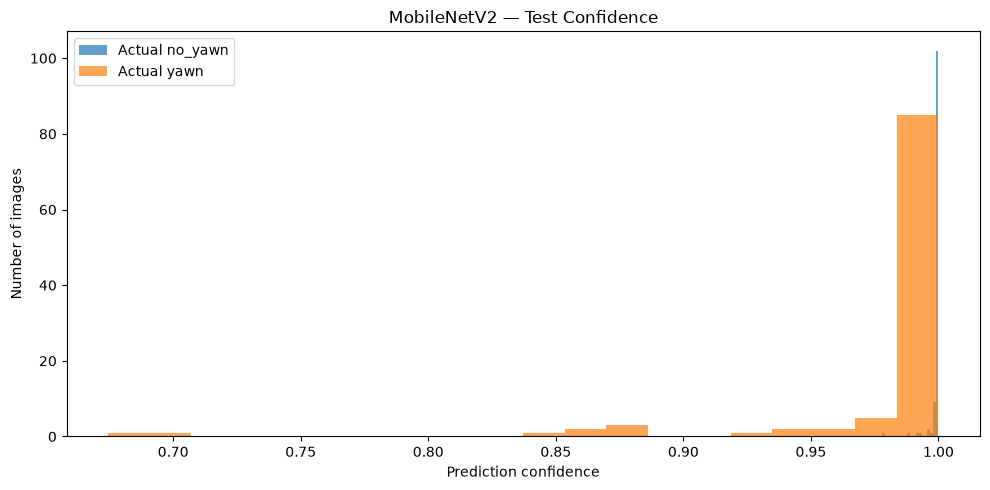

In [21]:
def plot_confidence_distribution(
    true_labels,
    probabilities,
    title
):
    confidence = np.where(
        probabilities >= 0.5,
        probabilities,
        1.0 - probabilities
    )

    plt.figure(figsize=(10, 5))

    plt.hist(
        confidence[true_labels == 0],
        bins=20,
        alpha=0.7,
        label="Actual no_yawn"
    )

    plt.hist(
        confidence[true_labels == 1],
        bins=20,
        alpha=0.7,
        label="Actual yawn"
    )

    plt.xlabel("Prediction confidence")
    plt.ylabel("Number of images")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_confidence_distribution(
    custom_true,
    custom_prob,
    "Custom CNN — Test Confidence"
)

plot_confidence_distribution(
    mobilenet_true,
    mobilenet_prob,
    "MobileNetV2 — Test Confidence"
)


## 20. Inspect incorrect MobileNetV2 predictions



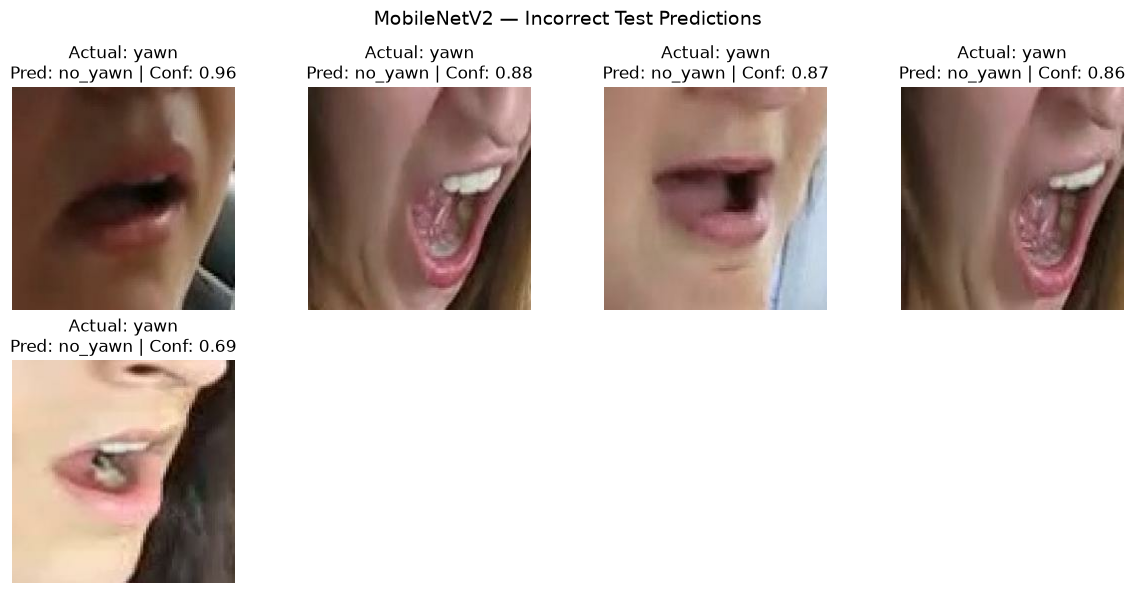

In [22]:
def show_misclassified_examples(
    model,
    dataset,
    title,
    max_examples=12
):
    all_images = []
    all_labels = []
    all_probabilities = []

    for images, labels in dataset:
        probs = model.predict(
            images,
            verbose=0
        ).reshape(-1)

        all_images.extend(
            images.numpy()
        )

        all_labels.extend(
            labels.numpy().reshape(-1).astype(int)
        )

        all_probabilities.extend(
            probs
        )

    all_images = np.asarray(all_images)
    all_labels = np.asarray(all_labels)
    all_probabilities = np.asarray(all_probabilities)

    predictions = (
        all_probabilities >= 0.50
    ).astype(int)

    wrong = np.where(
        predictions != all_labels
    )[0]

    if len(wrong) == 0:
        print("No misclassified test examples.")
        return

    # Show the most confident incorrect predictions first.
    wrong_confidence = np.where(
        predictions[wrong] == 1,
        all_probabilities[wrong],
        1.0 - all_probabilities[wrong]
    )

    ordered = wrong[
        np.argsort(-wrong_confidence)
    ]

    selected = ordered[
        :min(max_examples, len(ordered))
    ]

    cols = 4
    rows = int(np.ceil(len(selected) / cols))

    plt.figure(figsize=(12, 3 * rows))

    for i, index in enumerate(selected):
        ax = plt.subplot(rows, cols, i + 1)

        image = np.clip(
            all_images[index] / 255.0,
            0,
            1
        )

        ax.imshow(image)

        actual = CLASS_NAMES[
            all_labels[index]
        ]

        predicted = CLASS_NAMES[
            predictions[index]
        ]

        probability = all_probabilities[index]

        confidence = (
            probability
            if predictions[index] == 1
            else 1.0 - probability
        )

        ax.set_title(
            f"Actual: {actual}\n"
            f"Pred: {predicted} | "
            f"Conf: {confidence:.2f}"
        )

        ax.axis("off")

    plt.suptitle(
        title,
        fontsize=14
    )

    plt.tight_layout()
    plt.show()


show_misclassified_examples(
    mobilenet_model,
    test_ds,
    "MobileNetV2 — Incorrect Test Predictions"
)


## 21. Save metrics and training summary

In [23]:
summary = {
    "task": "Mouth State Classification",
    "classes": CLASS_NAMES,
    "image_size": list(IMG_SIZE),
    "batch_size": BATCH_SIZE,
    "training_counts": train_counts,
    "class_weights": {
        str(k): float(v)
        for k, v in class_weight.items()
    },
    "custom_cnn": {
        "accuracy": float(custom_metrics["accuracy"]),
        "precision": float(custom_metrics["precision"]),
        "recall": float(custom_metrics["recall"]),
        "f1": float(custom_metrics["f1"]),
        "confusion_matrix": (
            custom_metrics["confusion_matrix"]
            .tolist()
        ),
        "training_minutes": float(
            custom_training_minutes
        )
    },
    "mobilenetv2": {
        "accuracy": float(mobilenet_metrics["accuracy"]),
        "precision": float(mobilenet_metrics["precision"]),
        "recall": float(mobilenet_metrics["recall"]),
        "f1": float(mobilenet_metrics["f1"]),
        "confusion_matrix": (
            mobilenet_metrics["confusion_matrix"]
            .tolist()
        ),
        "stage1_minutes": float(stage1_minutes),
        "stage2_minutes": float(stage2_minutes)
    }
}

summary_path = (
    OUTPUT_DIR /
    "mouth_model_comparison_summary.json"
)

summary_path.write_text(
    json.dumps(
        summary,
        indent=2
    ),
    encoding="utf-8"
)

comparison_path = (
    OUTPUT_DIR /
    "mouth_model_comparison.csv"
)

comparison_df.to_csv(
    comparison_path,
    index=False
)

print(
    json.dumps(
        summary,
        indent=2
    )
)

print("\nSaved:")
print(summary_path)
print(comparison_path)


{
  "task": "Mouth State Classification",
  "classes": [
    "no_yawn",
    "yawn"
  ],
  "image_size": [
    224,
    224
  ],
  "batch_size": 32,
  "training_counts": {
    "no_yawn": 500,
    "yawn": 504
  },
  "class_weights": {
    "0": 1.004,
    "1": 0.996031746031746
  },
  "custom_cnn": {
    "accuracy": 0.5339366515837104,
    "precision": 0.0,
    "recall": 0.0,
    "f1": 0.0,
    "confusion_matrix": [
      [
        118,
        0
      ],
      [
        103,
        0
      ]
    ],
    "training_minutes": 10.221884107589721
  },
  "mobilenetv2": {
    "accuracy": 0.9773755656108597,
    "precision": 1.0,
    "recall": 0.9514563106796117,
    "f1": 0.9751243781094527,
    "confusion_matrix": [
      [
        118,
        0
      ],
      [
        5,
        98
      ]
    ],
    "stage1_minutes": 4.301934500535329,
    "stage2_minutes": 8.908016868432362
  }
}

Saved:
d:\driver-drowsiness-detection\outputs\mouth_model_comparison_summary.json
d:\driver-drowsiness-detect